## Data Profiling/data understanding:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# STEP 1: LOAD THE DATASET
df = pd.read_csv(
    '/content/DataCoSupplyChainDataset.csv',
    encoding='latin-1'
)


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 180519
Columns: 53


In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [ ]:
# Missing values
print(df.isnull().sum().sort_values(ascending=False))

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
Type                                  0
Department Id                         0
Customer Street                       0
Department Name                       0
Latitude                              0


In [ ]:
# Statistical summary
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [ ]:
# STEP 3: ALL COLUMN NAMES
print(f"\n📋 ALL COLUMNS:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


📋 ALL COLUMNS:
   1. Type
   2. Days for shipping (real)
   3. Days for shipment (scheduled)
   4. Benefit per order
   5. Sales per customer
   6. Delivery Status
   7. Late_delivery_risk
   8. Category Id
   9. Category Name
  10. Customer City
  11. Customer Country
  12. Customer Email
  13. Customer Fname
  14. Customer Id
  15. Customer Lname
  16. Customer Password
  17. Customer Segment
  18. Customer State
  19. Customer Street
  20. Customer Zipcode
  21. Department Id
  22. Department Name
  23. Latitude
  24. Longitude
  25. Market
  26. Order City
  27. Order Country
  28. Order Customer Id
  29. order date (DateOrders)
  30. Order Id
  31. Order Item Cardprod Id
  32. Order Item Discount
  33. Order Item Discount Rate
  34. Order Item Id
  35. Order Item Product Price
  36. Order Item Profit Ratio
  37. Order Item Quantity
  38. Sales
  39. Order Item Total
  40. Order Profit Per Order
  41. Order Region
  42. Order State
  43. Order Status
  44. Order Zipcode
  45. Prod

In [ ]:
# STEP 4: DATA TYPES
print(f"\n📌 DATA TYPES:")
print(df.dtypes.to_string())


📌 DATA TYPES:
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
M

In [ ]:
# ─────────────────────────────────────────
# STEP 5: NULL VALUES
# ─────────────────────────────────────────
print(f"\n⚠️  NULL VALUES:")
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({
    'null_count': nulls,
    'null_pct':   nulls_pct
}).query('null_count > 0').sort_values(
    'null_count', ascending=False
)
print(null_report.to_string())


⚠️  NULL VALUES:
                     null_count  null_pct
Product Description      180519    100.00
Order Zipcode            155679     86.24
Customer Lname                8      0.00
Customer Zipcode              3      0.00


In [ ]:
# ─────────────────────────────────────────
# STEP 6: DUPLICATE ROWS
# ─────────────────────────────────────────
print(f"\n🔁 DUPLICATE ROWS:")
print(f"  Total duplicates: {df.duplicated().sum():,}")


🔁 DUPLICATE ROWS:
  Total duplicates: 0


In [ ]:
# ─────────────────────────────────────────
# STEP 7: KEY COLUMN DISTRIBUTIONS
# ─────────────────────────────────────────
print(f"\n📦 DELIVERY STATUS:")
print(df['Delivery Status'].value_counts())
print(df['Delivery Status'].value_counts(
    normalize=True).round(3) * 100)

print(f"\n🚚 SHIPPING MODE:")
print(df['Shipping Mode'].value_counts())

print(f"\n🏪 ORDER STATUS:")
print(df['Order Status'].value_counts())

print(f"\n📁 DEPARTMENT NAME:")
print(df['Department Name'].value_counts())

print(f"\n👥 CUSTOMER SEGMENT:")
print(df['Customer Segment'].value_counts())

print(f"\n🌍 MARKET:")
print(df['Market'].value_counts())

print(f"\n⚠️  LATE DELIVERY RISK:")
print(df['Late_delivery_risk'].value_counts())


📦 DELIVERY STATUS:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64
Delivery Status
Late delivery        54.8
Advance shipping     23.0
Shipping on time     17.8
Shipping canceled     4.3
Name: proportion, dtype: float64

🚚 SHIPPING MODE:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

🏪 ORDER STATUS:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

📁 DEPARTMENT NAME:
Department Name
Fan Shop              66861
Apparel               48998
Golf                  33220
Footwear              14525
Outdoors               9686
Fitness                2479
Discs Shop             2026
Techno

In [ ]:
# ─────────────────────────────────────────
# STEP 8: NUMERIC COLUMN SUMMARY
# ─────────────────────────────────────────
print(f"\n📊 NUMERIC SUMMARY:")
numeric_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Sales',
    'Order Profit Per Order',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Benefit per order'
]
print(df[numeric_cols].describe().round(2).to_string())


📊 NUMERIC SUMMARY:
       Days for shipping (real)  Days for shipment (scheduled)      Sales  Order Profit Per Order  Order Item Quantity  Order Item Discount Rate  Benefit per order
count                 180519.00                      180519.00  180519.00               180519.00            180519.00                 180519.00          180519.00
mean                       3.50                           2.93     203.77                   21.97                 2.13                      0.10              21.97
std                        1.62                           1.37     132.27                  104.43                 1.45                      0.07             104.43
min                        0.00                           0.00       9.99                -4274.98                 1.00                      0.00           -4274.98
25%                        2.00                           2.00     119.98                    7.00                 1.00                      0.04               7

In [ ]:
# ─────────────────────────────────────────
# STEP 9: DATE RANGE
# ─────────────────────────────────────────
df['order_date_temp'] = pd.to_datetime(
    df['order date (DateOrders)'],
    format='mixed',
    errors='coerce'
)
print(f"\n📅 DATE RANGE:")
print(f"  Earliest: {df['order_date_temp'].min()}")
print(f"  Latest:   {df['order_date_temp'].max()}")
df.drop(columns=['order_date_temp'], inplace=True)


📅 DATE RANGE:
  Earliest: 2015-01-01 00:00:00
  Latest:   2018-01-31 23:38:00


## Data cleaning:

In [ ]:
# STEP 1: DROP USELESS COLUMNS
cols_to_drop = [
    'Product Description',  # 100% null
    'Product Image',        # URL — not needed
    'Customer Zipcode',     # mostly null
    'Order Zipcode',        # mostly null
    'Customer Password',    # masked — not useful
    'Customer Email',       # PII — not needed
    'Customer Fname',       # PII — not needed
    'Customer Lname',       # PII — not needed
    'Customer Street',      # too granular
    'Order Item Cardprod Id', # RFID code — not needed
]

df.drop(
    columns=cols_to_drop,
    errors='ignore',
    inplace=True
)
print(f"After dropping columns: {df.shape[1]} columns remain")

After dropping columns: 43 columns remain


In [ ]:
# check the duplicates in the data:
print("Duplicates before:", df.duplicated().sum())

Duplicates before: 0


remove cancelled orders: because we have only talk about the late delivery order... not the cancelled orders:

In [ ]:
# STEP 2: REMOVE CANCELLED ORDERS
before = len(df)

# Remove shipping cancelled
df = df[df['Delivery Status'] != 'Shipping canceled']

# Remove payment review and suspected fraud
df = df[~df['Order Status'].isin([
    'PAYMENT_REVIEW',
    'SUSPECTED_FRAUD'
])]

print(f"After removing cancelled: {len(df):,} rows")
print(f"Removed: {before - len(df):,} rows")

After removing cancelled: 170,872 rows
Removed: 9,647 rows


In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


change the type, also remove the time from the columns:

In [ ]:
# Step 1: Parse to datetime using Pandas
df['order_date'] = pd.to_datetime(
    df['order date (DateOrders)'],
    format='mixed',
    errors='coerce'
)

df['shipping_date'] = pd.to_datetime(
    df['shipping date (DateOrders)'],
    format='mixed',
    errors='coerce'
)

# Step 2: Strip time completely to keep ONLY the Date type (YYYY-MM-DD)
df['order_date'] = df['order_date'].dt.date
df['shipping_date'] = df['shipping_date'].dt.date

In [ ]:
# 7. Check invalid dates
print("Invalid order dates:",
      df["order_date"].isna().sum())

print("Invalid shipping dates:",
      df["shipping_date"].isna().sum())

Invalid order dates: 0
Invalid shipping dates: 0


In [ ]:
# 8. Check shipping-date logic

# Note: A shipment should not happen before the order.

invalid_dates = df[
    df["shipping_date"] < df["order_date"]
]

print("Invalid shipping dates:", len(invalid_dates))

Invalid shipping dates: 0


In [ ]:
# STEP 4: CLEAN COLUMN NAMES

df.rename(columns={
    'Type':                        'payment_type',
    'Days for shipping (real)':    'actual_shipping_days',
    'Days for shipment (scheduled)':'scheduled_shipping_days',
    'Benefit per order':           'benefit_per_order',
    'Sales per customer':          'sales_per_customer',
    'Delivery Status':             'delivery_status',
    'Late_delivery_risk':          'late_delivery_risk',
    'Category Id':                 'category_id',
    'Category Name':               'category_name',
    'Customer City':               'customer_city',
    'Customer Country':            'customer_country',
    'Customer Id':                 'customer_id',
    'Customer Segment':            'customer_segment',
    'Customer State':              'customer_state',
    'Department Id':               'department_id',
    'Department Name':             'department_name',
    'Latitude':                    'latitude',
    'Longitude':                   'longitude',
    'Market':                      'market',
    'Order City':                  'order_city',
    'Order Country':               'order_country',
    'Order Customer Id':           'order_customer_id',
    'order date (DateOrders)':     'order_date_raw',
    'Order Id':                    'order_id',
    'Order Item Discount':         'order_item_discount',
    'Order Item Discount Rate':    'order_item_discount_rate',
    'Order Item Id':               'order_item_id',
    'Order Item Product Price':    'product_price',
    'Order Item Profit Ratio':     'profit_ratio',
    'Order Item Quantity':         'quantity',
    'Sales':                       'sales',
    'Order Item Total':            'order_item_total',
    'Order Profit Per Order':      'profit_per_order',
    'Order Region':                'order_region',
    'Order State':                 'order_state',
    'Order Status':                'order_status',
    'Product Card Id':             'product_id',
    'Product Category Id':         'product_category_id',
    'Product Name':                'product_name',
    'Product Price':               'product_list_price',
    'Product Status':              'product_status',
    'shipping date (DateOrders)':  'shipping_date_raw',
    'Shipping Mode':               'shipping_mode',
}, inplace=True)

print(f"\n✅ Columns renamed")



✅ Columns renamed


In [ ]:
numeric_columns = [
    "days_for_shipping_real",
    "days_for_shipment_scheduled",
    "benefit_per_order",
    "sales_per_customer",
    "late_delivery_risk",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "order_profit_per_order",
    "product_price"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

In [ ]:
# 10. Check negative/invalid values

# for quantity check:
print(
    df[df["quantity"] <= 0]
    .shape
)

(0, 45)


In [ ]:
# Remove invalid quantities:

df = df[
    df["quantity"] > 0
]

In [ ]:
# Product price
df = df[
    df["product_price"] >= 0
]

In [ ]:
# Sales
df = df[
    df["sales"] >= 0
]

In [ ]:
# 11. Check delivery values
print(df["delivery_status"].value_counts())

delivery_status
Late delivery       97895
Advance shipping    41172
Shipping on time    31805
Name: count, dtype: int64


In [ ]:
# 12. Check order status
print(df["order_status"].value_counts())

order_status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
Name: count, dtype: int64


In [ ]:
df.head()

,payment_type,actual_shipping_days,scheduled_shipping_days,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_status,product_id,product_category_id,product_name,product_list_price,product_status,shipping_date_raw,shipping_mode,order_date,shipping_date
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,2018-01-31,2018-02-03
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class,2018-01-13,2018-01-18
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class,2018-01-13,2018-01-17
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,2018-01-13,2018-01-16
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,2018-01-13,2018-01-15


In [ ]:
df.shape

(170872, 45)

## Data Cleaning issues:

In [ ]:
# 1: benefits per order/ sales per customer

df[["benefit_per_order", "sales_per_customer"]] = df[
    ["benefit_per_order", "sales_per_customer"]
].round(2)

In [ ]:
print(df[["benefit_per_order", "sales_per_customer"]].head(5))

   benefit_per_order  sales_per_customer
0              91.25              314.64
1            -249.09              311.36
2            -247.78              309.72
3              22.86              304.81
4             134.21              298.25


In [ ]:
# 2: drop the shipping_date_raw, and order_date_raw columns
df.drop(
    columns=["shipping_date_raw", "order_date_raw"],
    inplace=True,
    errors="ignore"
)

In [ ]:
df.shape

(170872, 43)

In [ ]:
# 3: Remove leading and trailing spaces from all string columns
string_columns = [
    "payment_type",
    "delivery_status",
    "category_name",
    "customer_city",
    "customer_country",
    "customer_segment",
    "customer_state",
    "department_name",
    "market",
    "order_city",
    "order_country",
    "order_region",
    "order_state",
    "order_status",
    "product_name",
    "shipping_mode"
]

for col in string_columns:
    df[col] = df[col].str.strip()

In [ ]:
print(df["customer_country"].unique())

['Puerto Rico' 'EE. UU.']


In [ ]:
# 4: replace the spanish word to  the english:
df["customer_country"] = df["customer_country"].replace({
    "EE. UU.": "United States"
})

In [ ]:
print(df["customer_state"].unique())

['PR' 'CA' 'FL' 'NY' 'MA' 'IL' 'PA' 'MI' 'TX' 'GA' 'HI' 'AZ' 'CO' 'MD'
 'MN' 'NC' 'NJ' 'NM' 'OR' 'SC' 'VA' 'OH' 'UT' 'WA' 'KY' 'WV' 'RI' 'CT'
 'LA' 'TN' 'DC' 'ND' 'MO' 'IN' 'ID' 'MT' 'WI' 'NV' 'KS' 'DE' 'AR' 'OK'
 'AL' 'IA' '95758' '91732']


handle with the two number in this data:

In [ ]:
# Map zip codes to their correct state abbreviation
state_corrections = {
    '95758': 'CA',
    '91732': 'CA'
}

df['customer_state'] = df['customer_state'].replace(state_corrections)

# Verify dirty values are gone
print(df['customer_state'].unique())

['PR' 'CA' 'FL' 'NY' 'MA' 'IL' 'PA' 'MI' 'TX' 'GA' 'HI' 'AZ' 'CO' 'MD'
 'MN' 'NC' 'NJ' 'NM' 'OR' 'SC' 'VA' 'OH' 'UT' 'WA' 'KY' 'WV' 'RI' 'CT'
 'LA' 'TN' 'DC' 'ND' 'MO' 'IN' 'ID' 'MT' 'WI' 'NV' 'KS' 'DE' 'AR' 'OK'
 'AL' 'IA']


In [ ]:
print(df["customer_city"].unique())

['Caguas' 'San Jose' 'Los Angeles' 'Miami' 'San Ramon' 'Freeport'
 'Salinas' 'Peabody' 'Canovanas' 'Paramount' 'Mount Prospect' 'Long Beach'
 'Rancho Cordova' 'Wilkes Barre' 'Roseville' 'Bellflower' 'Wheaton'
 'Detroit' 'Dallas' 'Carlisle' 'Panorama City' 'Atlanta' 'Fremont'
 'Rochester' 'Bayamon' 'Guayama' 'Juana Diaz' 'Ontario' 'Oviedo' 'Buffalo'
 'Honolulu' 'Oceanside' 'North Tonawanda' 'Clovis' 'Jamaica'
 'Granite City' 'Medford' 'Pomona' 'Tempe' 'Santa Ana' 'York' 'Aurora'
 'Simi Valley' 'Silver Spring' 'Saint Paul' 'San Antonio' 'Philadelphia'
 'Bronx' 'Greenville' 'Morristown' 'San Diego' 'Oxnard' 'Albuquerque'
 'Amarillo' 'Lutz' 'Bend' 'East Brunswick' 'Lancaster' 'Houston' 'Hampton'
 'New York' 'Porterville' 'Portland' 'Strongsville' 'El Paso' 'Del Rio'
 'Bountiful' 'Kent' 'Chicago' 'Plymouth' 'Far Rockaway' 'Garden Grove'
 'Placentia' 'Mentor' 'Santa Clara' 'Union' 'Westminster' 'Pompano Beach'
 'Azusa' 'Fort Lauderdale' 'Princeton' 'Perth Amboy' 'Loveland'
 'Virginia Beach' 

In [ ]:
df[df["customer_city"] == "CA"]

,payment_type,actual_shipping_days,scheduled_shipping_days,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_state,order_status,product_id,product_category_id,product_name,product_list_price,product_status,shipping_mode,order_date,shipping_date
35704,DEBIT,2,1,66.38,189.66,Late delivery,1,65,Consumer Electronics,CA,...,Auvernia-Ródano-Alpes,COMPLETE,1352,65,Industrial consumer electronics,252.880005,0,First Class,2017-11-02,2017-11-04
46440,PAYMENT,4,4,10.91,38.96,Shipping on time,0,75,Video Games,CA,...,Capital Nacional,PENDING_PAYMENT,1362,75,Fighting video games,39.750000,0,Standard Class,2017-12-10,2017-12-14
82511,DEBIT,4,4,59.99,299.96,Shipping on time,0,63,Children's Clothing,CA,...,Inglaterra,COMPLETE,1350,63,Children's heaters,357.100006,0,Standard Class,2017-10-26,2017-10-30


In [ ]:
print((df["customer_city"] == "CA").sum())

3


In [ ]:
# Replace 'CA' in customer_city with 'Unknown'
df['customer_city'] = df['customer_city'].replace({'CA': 'Unknown'})

# Verify the fix
print("Remaining 'CA' entries in city column:", (df['customer_city'] == 'CA').sum())

Remaining 'CA' entries in city column: 0


In [ ]:
# Check data types of specific date columns
print(df[['order_date', 'shipping_date']].dtypes)

# Inspect sample values to confirm structure
print(df[['order_date', 'shipping_date']].head())

order_date       object
shipping_date    object
dtype: object
   order_date shipping_date
0  2018-01-31    2018-02-03
1  2018-01-13    2018-01-18
2  2018-01-13    2018-01-17
3  2018-01-13    2018-01-16
4  2018-01-13    2018-01-15


check the null values in the data:

In [ ]:
# Check total null counts and percentage per column
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# Display only columns that have missing values
null_summary[null_summary['Null Count'] > 0].sort_values(by='Null Count', ascending=False)

,Null Count,Null Percentage (%)


In [ ]:
df.columns

Index(['payment_type', 'actual_shipping_days', 'scheduled_shipping_days',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_id', 'customer_segment', 'customer_state',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id', 'order_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'product_price', 'profit_ratio', 'quantity', 'sales',
       'order_item_total', 'profit_per_order', 'order_region', 'order_state',
       'order_status', 'product_id', 'product_category_id', 'product_name',
       'product_list_price', 'product_status', 'shipping_mode', 'order_date',
       'shipping_date'],
      dtype='object')

In [ ]:
df.shape

(170872, 43)

In [ ]:
# Select and view the first 10 rows of latitude and longitude
df[['latitude', 'longitude']].head(10)

,latitude,longitude
0,18.251453,-66.037056
1,18.279451,-66.037064
2,37.292233,-121.881279
3,34.125946,-118.291016
4,18.253769,-66.037048
6,18.242538,-66.037056
7,25.928869,-80.162872
8,18.233223,-66.037056
9,37.773991,-121.966629
11,40.654865,-73.587074


In [ ]:
df['latitude'] = df['latitude'].round(2)
df['longitude'] = df['longitude'].round(2)

# Verify output
df[['latitude', 'longitude']].head(10)

,latitude,longitude
0,18.25,-66.04
1,18.28,-66.04
2,37.29,-121.88
3,34.13,-118.29
4,18.25,-66.04
6,18.24,-66.04
7,25.93,-80.16
8,18.23,-66.04
9,37.77,-121.97
11,40.65,-73.59


In [ ]:
df['order_city'].unique()

array(['Bekasi', 'Bikaner', 'Townsville', ..., 'Liuyang', 'Nashua',
       'Junín'], dtype=object)

In [ ]:
# Option 2: Print line-by-line with row index
unique_cities = df['order_city'].dropna().unique()
for idx, city in enumerate(unique_cities, 1):
    print(f"{idx}. {city}")

print(f"\nTotal Unique Order Cities: {len(unique_cities)}")

1. Bekasi
2. Bikaner
3. Townsville
4. Guangzhou
5. Manado
6. Sangli
7. Seúl
8. Jabalpur
9. Geelong
10. Mandurah
11. Guilin
12. Delhi
13. Suzhou
14. Singapur
15. Hubli
16. Wollongong
17. Medan
18. Canberra
19. Bangalore
20. Yiwu
21. Mirzapur
22. Bursa
23. Murray Bridge
24. Kartal
25. Ulan Bator
26. Estambul
27. Raipur
28. Pasco
29. Los Angeles
30. San Francisco
31. Overland Park
32. Ugep
33. Kinshasa
34. Dakar
35. Casablanca
36. Dortmund
37. Drancy
38. Nantes
39. Groningen
40. Gateshead
41. Eastbourne
42. Hayange
43. Portsmouth
44. Gelsenkirchen
45. Nice
46. Petapa
47. Mejicanos
48. David
49. Santo Domingo
50. Cabimas
51. Dos Quebradas
52. Ilopango
53. Tegucigalpa
54. Juazeiro
55. Mexico City
56. Tlaquepaque
57. Puebla
58. São Paulo
59. Montevideo
60. Buenos Aires
61. Barueri
62. Arapongas
63. Camagüey
64. Las Tunas
65. Tepic
66. San Miguelito
67. Ixtapaluca
68. Maceió
69. Belo Horizonte
70. Santiago de Cuba
71. San Pedro Sula
72. Lima
73. Holguín
74. Orizaba
75. Managua
76. Villahermos

In [ ]:
import unicodedata

def remove_accents(text):
    if pd.isna(text):
        return text
    # Normalize unicode characters and remove diacritics/accents
    nfkd_form = unicodedata.normalize('NFKD', str(text))
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

# Remove accents (e.g., 'Bogotá' -> 'Bogota', 'Medellín' -> 'Medellin')
df['order_city'] = df['order_city'].apply(remove_accents)

In [ ]:
df['order_city'].unique()

array(['Bekasi', 'Bikaner', 'Townsville', ..., 'Liuyang', 'Nashua',
       'Junin'], dtype=object)

In [ ]:
# check the order region:
df['order_region'].unique()


array(['Southeast Asia', 'South Asia', 'Oceania', 'Eastern Asia',
       'West Asia', 'West of USA', 'US Center', 'West Africa',
       'Central Africa', 'North Africa', 'Western Europe',
       'Northern Europe', 'Central America', 'Caribbean', 'South America',
       'East Africa', 'Southern Europe', 'Southern Africa',
       'Central Asia', 'Eastern Europe', 'East of USA', 'South of  USA',
       'Canada'], dtype=object)

In [ ]:
# List key text columns to audit
text_cols = ['order_city', 'customer_city', 'order_country', 'customer_state', 'category_name']

# Inspect unique values to spot casing issues (e.g., 'san jose' vs 'San Jose' vs 'SAN JOSE')
for col in text_cols:
    if col in df.columns:
        print(f"--- Unique values sample for {col} ---")
        print(df[col].dropna().unique()[:10])

--- Unique values sample for order_city ---
['Bekasi' 'Bikaner' 'Townsville' 'Guangzhou' 'Manado' 'Sangli' 'Seul'
 'Jabalpur' 'Geelong' 'Mandurah']
--- Unique values sample for customer_city ---
['Caguas' 'San Jose' 'Los Angeles' 'Miami' 'San Ramon' 'Freeport'
 'Salinas' 'Peabody' 'Canovanas' 'Paramount']
--- Unique values sample for order_country ---
['Indonesia' 'India' 'Australia' 'China' 'Corea del Sur' 'Singapur'
 'Turquía' 'Mongolia' 'Estados Unidos' 'Nigeria']
--- Unique values sample for customer_state ---
['PR' 'CA' 'FL' 'NY' 'MA' 'IL' 'PA' 'MI' 'TX' 'GA']
--- Unique values sample for category_name ---
['Sporting Goods' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Boxing & MMA' 'Cardio Equipment' 'Trade-In' "Kids' Golf Clubs"
 'Hunting & Shooting']


In [ ]:
# Apply Title Case (e.g., 'SAN JOSE' or 'san jose' -> 'San Jose')
title_case_cols = ['order_city', 'customer_city', 'category_name', 'department_name']
for col in title_case_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Apply Uppercase (e.g., state codes like 'ca' -> 'CA', or countries 'usa' -> 'USA')
upper_case_cols = ['customer_state', 'order_country', 'customer_country']
for col in upper_case_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

In [ ]:
# 1. Clean extra spaces and apply proper casing
city_cat_cols = ['order_city', 'customer_city', 'category_name']
for col in city_cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# State abbreviations should strictly be uppercase
if 'customer_state' in df.columns:
    df['customer_state'] = df['customer_state'].astype(str).str.strip().str.upper()

# 2. Fix Spanish country names
country_map = {
    'Estados Unidos': 'United States',
    'EE. UU.': 'United States',
    'Corea del Sur': 'South Korea',
    'Singapur': 'Singapore',
    'Turquía': 'Turkey'
}
df['order_country'] = df['order_country'].replace(country_map).str.strip().str.title()

# 3. Fix key Spanish city names
city_map = {
    'Seul': 'Seoul',
    'Pekin': 'Beijing',
    'Sevilla': 'Seville'
}
df['order_city'] = df['order_city'].replace(city_map)

In [ ]:
df['customer_country'].unique()

array(['PUERTO RICO', 'EE. UU.'], dtype=object)

In [ ]:
# Replace 'EE. UU.' with 'United States' and standardize casing
country_map = {
    'EE. UU.': 'United States',
    'PUERTO RICO': 'Puerto Rico'
}

df['customer_country'] = df['customer_country'].replace(country_map)

# Verify output
print(df['customer_country'].unique())
# Output: array(['Puerto Rico', 'United States'], dtype=object)

['Puerto Rico' 'United States']


In [ ]:
# Final clean-up: Strip extra spaces & confirm Title Case across city fields
df['customer_city'] = df['customer_city'].astype(str).str.strip().str.title()
df['order_city'] = df['order_city'].astype(str).str.strip().str.title()

# Verify no extra leading/trailing spaces exist
print("Total unique customer cities:", df['customer_city'].nunique())

Total unique customer cities: 563


In [ ]:
# Strip leading/trailing spaces and collapse multiple inner spaces into one
df['product_name'] = df['product_name'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

# Verify clean unique values
print(df['product_name'].unique())

['Smart watch' 'Perfect Fitness Perfect Rip Deck'
 "Under Armour Girls' Toddler Spine Surge Runni"
 "Nike Men's Dri-FIT Victory Golf Polo"
 "Under Armour Men's Compression EV SL Slide"
 "Under Armour Women's Micro G Skulpt Running S"
 "Nike Men's Free 5.0+ Running Shoe"
 "Glove It Women's Mod Oval 3-Zip Carry All Gol"
 'Bridgestone e6 Straight Distance NFL San Dieg'
 "Columbia Men's PFG Anchor Tough T-Shirt" 'Titleist Pro V1x Golf Balls'
 'Bridgestone e6 Straight Distance NFL Tennesse'
 'Polar FT4 Heart Rate Monitor' 'ENO Atlas Hammock Straps'
 "adidas Men's F10 Messi TRX FG Soccer Cleat"
 "Brooks Women's Ghost 6 Running Shoe"
 "Nike Men's CJ Elite 2 TD Football Cleat"
 "Diamondback Women's Serene Classic Comfort Bi"
 'Industrial consumer electronics' 'Web Camera' 'Dell Laptop'
 'SOLE E25 Elliptical' 'Elevation Training Mask 2.0'
 "Nike Men's Deutschland Weltmeister Winners Bl"
 'Team Golf St. Louis Cardinals Putter Grip' 'Summer dresses'
 'Porcelain crafts' "Men's gala suit"
 'Team Go

In [ ]:
df.head()

,payment_type,actual_shipping_days,scheduled_shipping_days,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_state,order_status,product_id,product_category_id,product_name,product_list_price,product_status,shipping_mode,order_date,shipping_date
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,Standard Class,2018-01-31,2018-02-03
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,Smart watch,327.75,0,Standard Class,2018-01-13,2018-01-18
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,Standard Class,2018-01-13,2018-01-17
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,Standard Class,2018-01-13,2018-01-16
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,Standard Class,2018-01-13,2018-01-15


## Feature-Engineering:

In [ ]:
# 5a. Delay days
# Positive = late | Negative = early
df['delay_days'] = (
    df['actual_shipping_days'] -
    df['scheduled_shipping_days']
)

In [ ]:
# 5b. Is late flag (binary)
df['is_late'] = (
    df['delay_days'] > 0
).astype(int)

In [ ]:
# Verify matches existing column
print(f"\nIs_late vs Late_delivery_risk match:")
print(df[['is_late','late_delivery_risk']].value_counts())


Is_late vs Late_delivery_risk match:
is_late  late_delivery_risk
1        1                     97895
0        0                     72977
Name: count, dtype: int64


In [ ]:
# 5c. Profit margin %
df['profit_margin_pct'] = (
    df['profit_per_order'] /
    df['sales'].replace(0, np.nan) * 100
).round(2)

In [ ]:
# 5d. Revenue at risk
# Revenue from late orders
df['revenue_at_risk'] = df.apply(
    lambda r: r['sales'] if r['is_late'] == 1 else 0,
    axis=1
)

In [ ]:
# 5e. Date parts
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year']       = df['order_date'].dt.year
df['order_month']      = df['order_date'].dt.month
df['order_quarter']    = df['order_date'].dt.quarter
df['order_month_name'] = df['order_date'].dt.strftime('%b')
df['order_yearmonth']  = df['order_date'].dt.to_period('M').astype(str)
df['order_dayofweek']  = df['order_date'].dt.day_name()
df['order_week']       = df['order_date'].dt.isocalendar().week.astype(int)

In [ ]:
# 5f. Discount flag
df['has_discount'] = (
    df['order_item_discount'] > 0
).astype(int)

In [ ]:
df['order_year'].head()

,order_year
0,2018
1,2018
2,2018
3,2018
4,2018


In [ ]:
# check the cageorical missing values:

categorical_columns = [
    "category_name",
    "customer_segment",
    "market",
    "order_region",
    "order_country",
    "shipping_mode",
    "delivery_status",
    "order_status"
]

for col in categorical_columns:
    if col in df.columns:
        print(
            f"\n{col}:",
            df[col].isna().sum()
        )


category_name: 0

customer_segment: 0

market: 0

order_region: 0

order_country: 0

shipping_mode: 0

delivery_status: 0

order_status: 0


In [ ]:
# STEP 8: REMOVE OUTLIERS

# Sales outliers
Q1  = df['sales'].quantile(0.25)
Q3  = df['sales'].quantile(0.75)
IQR = Q3 - Q1
before = len(df)

df = df[
    (df['sales'] >= Q1 - 3 * IQR) &
    (df['sales'] <= Q3 + 3 * IQR)
]
print(f"\nOutliers removed: {before - len(df):,}")
print(f"Rows remaining:   {len(df):,}")



Outliers removed: 445
Rows remaining:   170,427


In [ ]:
# STEP 9: HANDLE REMAINING NULLS

print(f"\n⚠️  REMAINING NULLS:")
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(remaining_nulls)

# Fill numeric nulls with 0
numeric_nulls = [
    'order_item_discount',
    'order_item_discount_rate',
    'profit_margin_pct'
]
for col in numeric_nulls:
    if col in df.columns:
        df[col].fillna(0, inplace=True)

# Fill categorical nulls
if 'customer_city' in df.columns:
    df['customer_city'].fillna('Unknown', inplace=True)


⚠️  REMAINING NULLS:
Series([], dtype: int64)


In [ ]:
# STEP 6: ABC ANALYSIS
# (Classify products by revenue contribution)
# ═════════════════════════════════════════
product_revenue = df.groupby('product_name')['sales'] \
                    .sum().reset_index()
product_revenue = product_revenue.sort_values(
    'sales', ascending=False
)
product_revenue['cumulative_revenue'] = \
    product_revenue['sales'].cumsum()
product_revenue['cumulative_pct'] = (
    product_revenue['cumulative_revenue'] /
    product_revenue['sales'].sum()
)

# Assign ABC class
product_revenue['abc_class'] = 'C'
product_revenue.loc[
    product_revenue['cumulative_pct'] <= 0.70,
    'abc_class'] = 'A'
product_revenue.loc[
    (product_revenue['cumulative_pct'] > 0.70) &
    (product_revenue['cumulative_pct'] <= 0.90),
    'abc_class'] = 'B'

# Merge back to main dataset
df = df.merge(
    product_revenue[['product_name', 'abc_class']],
    on='product_name',
    how='left'
)

print(f"\n📦 ABC ANALYSIS:")
print(df['abc_class'].value_counts())
print(f"\nRevenue by ABC class:")
print(df.groupby('abc_class')['sales'].sum().round(0))


📦 ABC ANALYSIS:
abc_class
A    84023
B    64046
C    22358
Name: count, dtype: int64

Revenue by ABC class:
abc_class
A    21102187.0
B     9607379.0
C     3451210.0
Name: sales, dtype: float64


In [ ]:
# STEP 7: SUPPLIER PROXY SCORING
# (Dataset has no supplier column —
#  use Department + Shipping Mode as proxy)
# ═════════════════════════════════════════
df['supplier_proxy'] = (
    df['department_name'] + ' — ' +
    df['shipping_mode']
)

# Calculate supplier performance
supplier_stats = df.groupby('supplier_proxy').agg(
    total_orders    = ('order_id', 'count'),
    late_orders     = ('is_late', 'sum'),
    avg_delay       = ('delay_days', 'mean'),
    total_revenue   = ('sales', 'sum'),
    total_profit    = ('profit_per_order', 'sum')
).reset_index()

supplier_stats['on_time_rate'] = (
    1 - supplier_stats['late_orders'] /
    supplier_stats['total_orders']
) * 100

# Risk flag
supplier_stats['risk_flag'] = 'GREEN'
supplier_stats.loc[
    supplier_stats['on_time_rate'] < 75,
    'risk_flag'] = 'AMBER'
supplier_stats.loc[
    supplier_stats['on_time_rate'] < 60,
    'risk_flag'] = 'RED'

print(f"\n🏭 SUPPLIER PROXY RISK FLAGS:")
print(supplier_stats['risk_flag'].value_counts())


🏭 SUPPLIER PROXY RISK FLAGS:
risk_flag
RED      36
AMBER     8
Name: count, dtype: int64


In [ ]:
# STEP 10: FINAL VALIDATION
# ═════════════════════════════════════════
print(f"\n" + "=" * 60)
print("FINAL VALIDATION REPORT")
print("=" * 60)
print(f"Final rows:          {len(df):,}")
print(f"Final columns:       {df.shape[1]}")
print(f"Null values:         {df.isnull().sum().sum()}")
print(f"Duplicate rows:      {df.duplicated().sum()}")
print(f"Date range:          {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Delivery statuses:   {df['delivery_status'].unique()}")
print(f"Late orders:         {df['is_late'].sum():,} ({df['is_late'].mean()*100:.1f}%)")
print(f"ABC A products:      {(df['abc_class']=='A').sum():,}")
print(f"ABC B products:      {(df['abc_class']=='B').sum():,}")
print(f"ABC C products:      {(df['abc_class']=='C').sum():,}")
print(f"Revenue at risk:     ${df['revenue_at_risk'].sum():,.0f}")
print(f"Total sales:         ${df['sales'].sum():,.0f}")
print(f"Total profit:        ${df['profit_per_order'].sum():,.0f}")

print(f"\n✅ DATA CLEANING COMPLETE")


FINAL VALIDATION REPORT
Final rows:          170,427
Final columns:       57
Null values:         0
Duplicate rows:      0
Date range:          2015-01-01 → 2018-01-31
Delivery statuses:   ['Advance shipping' 'Late delivery' 'Shipping on time']
Late orders:         97,660 (57.3%)
ABC A products:      84,023
ABC B products:      64,046
ABC C products:      22,358
Revenue at risk:     $19,555,004
Total sales:         $34,160,776
Total profit:        $3,697,095

✅ DATA CLEANING COMPLETE


save the clean dataset:

In [ ]:
# STEP 11: SAVE CLEAN FILES

# Main clean dataset
df.to_csv(
    '/content/supply_chain_clean.csv',
    index=False
)
print(f"✅ supply_chain_clean.csv saved")

# Supplier scorecard
supplier_stats.to_csv(
    '/content/supplier_scorecard.csv',
    index=False
)
print(f"✅ supplier_scorecard.csv saved")

# Product ABC classification
product_revenue.to_csv(
    '/content/product_abc.csv',
    index=False
)
print(f"✅ product_abc.csv saved")

# Summary stats for validation
summary = {
    'total_rows':        len(df),
    'total_columns':     df.shape[1],
    'late_orders':       int(df['is_late'].sum()),
    'late_rate_pct':     round(df['is_late'].mean()*100, 2),
    'total_sales':       round(df['sales'].sum(), 2),
    'total_profit':      round(df['profit_per_order'].sum(), 2),
    'revenue_at_risk':   round(df['revenue_at_risk'].sum(), 2),
    'abc_A_products':    int((df['abc_class']=='A').sum()),
    'abc_B_products':    int((df['abc_class']=='B').sum()),
    'abc_C_products':    int((df['abc_class']=='C').sum()),
}

import json
with open('/content/cleaning_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ cleaning_summary.json saved")
print(f"\n🎉 ALL FILES SAVED TO data/clean/")

✅ supply_chain_clean.csv saved
✅ supplier_scorecard.csv saved
✅ product_abc.csv saved
✅ cleaning_summary.json saved

🎉 ALL FILES SAVED TO data/clean/


## EDA(Exploratory Data Analysis):

In [ ]:
df.shape

(170427, 57)

In [ ]:
df.head()

,payment_type,actual_shipping_days,scheduled_shipping_days,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_year,order_month,order_quarter,order_month_name,order_yearmonth,order_dayofweek,order_week,has_discount,abc_class,supplier_proxy
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,2018,1,1,Jan,2018-01,Wednesday,5,1,C,Fitness — Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,...,2018,1,1,Jan,2018-01,Saturday,2,1,C,Fitness — Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,...,2018,1,1,Jan,2018-01,Saturday,2,1,C,Fitness — Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,...,2018,1,1,Jan,2018-01,Saturday,2,1,C,Fitness — Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,2018,1,1,Jan,2018-01,Saturday,2,1,C,Fitness — Standard Class


basic EDA:

In [ ]:
print("Total Orders:", df["order_id"].nunique())
print("Total Records:", len(df))

print("Total Sales:", df["sales"].sum())
print("Total Profit:", df["profit_per_order"].sum())

print("Average Delay:",
      df["delay_days"].mean())

print("Late Delivery Rate:",
      df["is_late"].mean() * 100)


# this is the basic health supply chain metrics:

Total Orders: 61773
Total Records: 170427
Total Sales: 34160776.24674915
Total Profit: 3697094.973621506
Average Delay: 0.5653798987249673
Late Delivery Rate: 57.30312685196595


In [ ]:
# 3. Delivery Status Analysis
delivery_status = (
    df["delivery_status"]
    .value_counts()
)

print(delivery_status)

delivery_status
Late delivery       97660
Advance shipping    41051
Shipping on time    31716
Name: count, dtype: int64


In [ ]:
# Percentage:

delivery_percentage = (
    df["delivery_status"]
    .value_counts(normalize=True) * 100
)

print(delivery_percentage)

delivery_status
Late delivery       57.303127
Advance shipping    24.087146
Shipping on time    18.609727
Name: proportion, dtype: float64


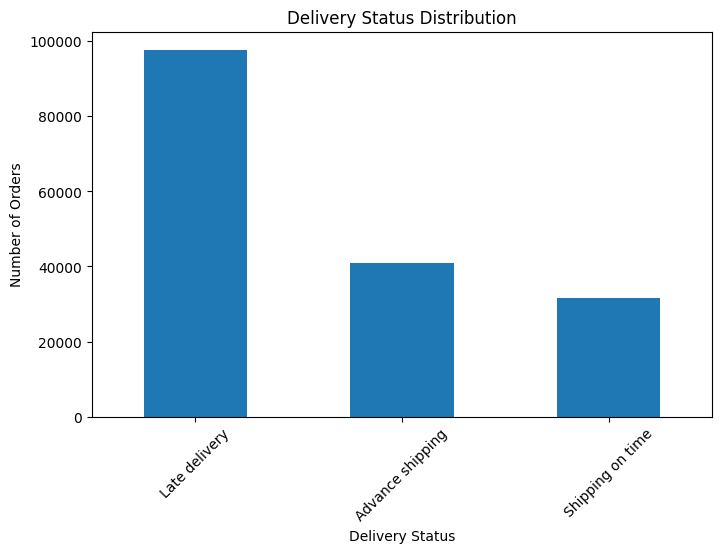

In [ ]:
# Visualization
delivery_status.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 4. Late Delivery Analysis
late_summary = df.groupby("is_late").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum"),
    avg_delay=("delay_days", "mean")
)

print(late_summary)

         orders         sales        profit  avg_delay
is_late                                               
0         26352  1.460577e+07  1.614469e+06  -0.847087
1         35421  1.955500e+07  2.082626e+06   1.617817


In [ ]:
# 5. Category Bottleneck Analysis

# This is one of the most important analyses.

category_analysis = df.groupby("category_name").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean")
)

category_analysis["late_rate"] = (
    category_analysis["late_orders"]
    / category_analysis["orders"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "late_rate",
    ascending=False
)

print(category_analysis)

# Now you can find:

# Which product categories have the highest delivery delay rate?

                      orders         sales         profit  late_orders  \
category_name                                                            
Cleats                 19313  4.196422e+06  468074.729825        13343   
Golf Bags & Carts         61  1.036939e+04    1810.069992           42   
Men'S Footwear         17786  2.738499e+06  295618.550147        12005   
Women'S Apparel        16881  2.976900e+06  329299.299537        11340   
Indoor/Outdoor Games   15723  2.733006e+06  298366.210502        10437   
Fishing                14373  6.567272e+06  725166.106991         9405   
Water Sports           13038  2.951253e+06  306006.390043         8432   
Camping & Hiking       11658  3.904540e+06  403839.898196         7409   
Cardio Equipment       10729  3.493263e+06  357854.098558         6728   
Lacrosse                 324  3.751533e+04    3931.539986          203   
Shop By Sport           9587  1.236680e+06  123874.560332         5984   
Strength Training         93  2.411769

In [ ]:
# 6. Regional Bottleneck Analysis
region_analysis = df.groupby("order_region").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean")
)

region_analysis["late_rate"] = (
    region_analysis["late_orders"]
    / region_analysis["orders"]
    * 100
)

region_analysis = region_analysis.sort_values(
    "late_rate",
    ascending=False
)

print(region_analysis)

# This tells you:

# Which regions are causing the biggest delivery bottlenecks?

                 orders         sales         profit  late_orders  avg_delay  \
order_region                                                                   
Central Africa      527  3.117299e+05   32029.710000          956   0.620927   
South of  USA      1265  7.366862e+05   80939.029920         2218   0.591268   
East Africa         583  3.601070e+05   41373.219946         1021   0.584799   
Eastern Europe     1234  7.412068e+05   77208.319950         2161   0.585535   
US Center          1825  1.090776e+06  125729.939910         3192   0.591382   
North Africa       1005  6.027350e+05   58591.890046         1747   0.553816   
East of USA        2199  1.298685e+06  146644.650179         3810   0.588109   
Central America    8897  5.372282e+06  579659.750743        15349   0.556887   
West Asia          1910  1.105503e+06  113532.549906         3277   0.568350   
South America      4682  2.777993e+06  311345.200780         8028   0.560574   
Central Asia        179  1.067504e+05   

In [ ]:
# 7. Shipping Mode Analysis
shipping_analysis = df.groupby("shipping_mode").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean")
)

shipping_analysis["late_rate"] = (
    shipping_analysis["late_orders"]
    / shipping_analysis["orders"]
    * 100
)

shipping_analysis = shipping_analysis.sort_values(
    "late_rate",
    ascending=False
)

print(shipping_analysis)

# This can reveal something like:

# Shipping Mode      Late Rate
# Standard Class       XX%
# Second Class         XX%
# First Class          XX%
# Same Day             XX%

                orders         sales  late_orders  avg_delay   late_rate
shipping_mode                                                           
First Class       9435  5.257351e+06        26141   1.000000  277.064123
Second Class     12046  6.674635e+06        26623   1.992653  221.011124
Same Day          3351  1.811513e+06         4415   0.480780  131.751716
Standard Class   36941  2.041728e+07        40481  -0.006398  109.582848


In [ ]:
# 8. Market Analysis
market_analysis = df.groupby("market").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean")
)

market_analysis["late_rate"] = (
    market_analysis["late_orders"]
    / market_analysis["orders"]
    * 100
)

print(
    market_analysis.sort_values(
        "late_rate",
        ascending=False
    )
)

              orders         sales        profit  late_orders  avg_delay  \
market                                                                     
USCA            8092  4.780011e+06  5.338844e+05        13951   0.571652   
Africa          3658  2.188245e+06  2.374601e+05         6280   0.562223   
LATAM          16226  9.711306e+06  1.055276e+06        27756   0.555982   
Europe         17229  9.758562e+06  1.071434e+06        27284   0.570796   
Pacific Asia   16568  7.722653e+06  7.990405e+05        22389   0.567546   

               late_rate  
market                    
USCA          172.404844  
Africa        171.678513  
LATAM         171.058795  
Europe        158.360903  
Pacific Asia  135.133993  


In [ ]:
# 9. Customer Segment Analysis
segment_analysis = df.groupby("customer_segment").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean")
)

segment_analysis["late_rate"] = (
    segment_analysis["late_orders"]
    / segment_analysis["orders"]
    * 100
)

print(segment_analysis)

                  orders         sales        profit  late_orders  avg_delay  \
customer_segment                                                               
Consumer           32027  1.770600e+07  1.918521e+06        50552   0.565893   
Corporate          18682  1.039366e+07  1.121660e+06        29594   0.556951   
Home Office        11064  6.061120e+06  6.569138e+05        17514   0.578253   

                   late_rate  
customer_segment              
Consumer          157.841821  
Corporate         158.409164  
Home Office       158.297180  


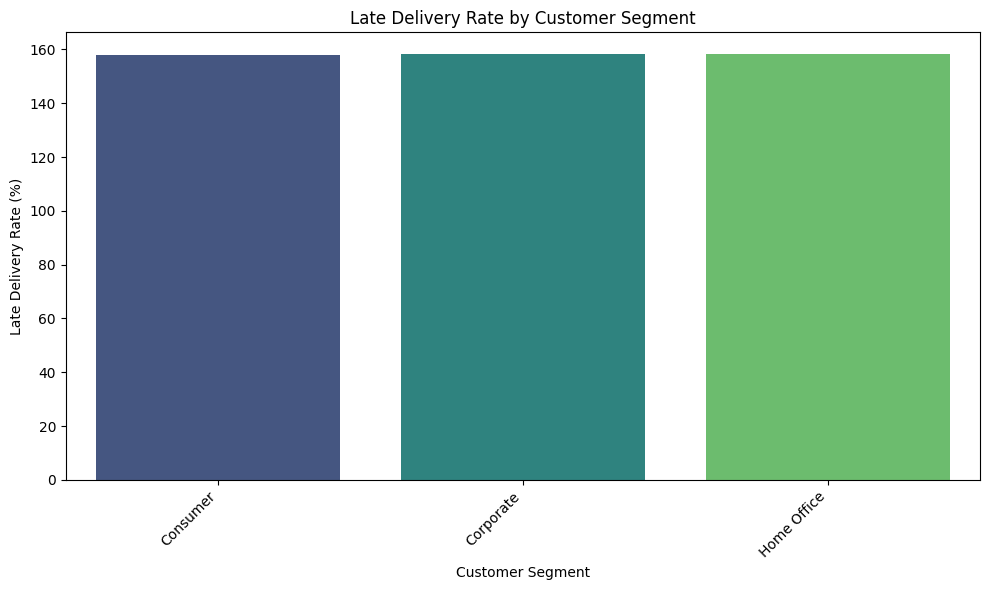

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=segment_analysis.index, y='late_rate', data=segment_analysis, ax=ax, palette='viridis')
ax.set_title('Late Delivery Rate by Customer Segment')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

                        orders         sales         profit  late_orders  \
order_year order_month                                                     
2015       1              1694  9.999067e+05  104174.700171         2855   
           2              1486  8.709182e+05   90796.940192         2570   
           3              1683  9.977593e+05  105569.250258         2900   
           4              1614  9.554977e+05   99911.259953         2729   
           5              1669  9.865538e+05  109526.900028         2935   
           6              1636  9.715299e+05  103893.530330         2757   
           7              1688  9.954648e+05  110755.339927         2913   
           8              1659  9.725595e+05  111721.100224         2903   
           9              1616  9.666011e+05  108039.570180         2876   
           10             1679  9.966325e+05   95440.520095         2880   
           11             1642  9.797054e+05   98954.190156         2798   
           1

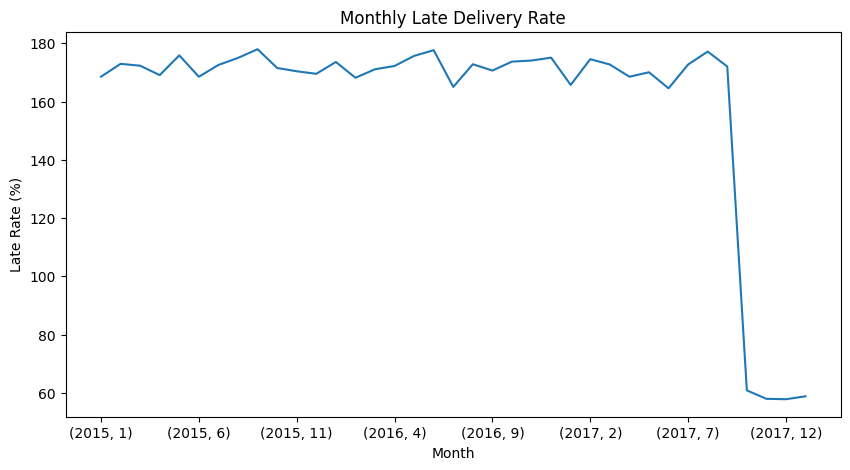

In [ ]:
# 10. Monthly Trend Analysis

# This is important for finding seasonal bottlenecks.

monthly_analysis = df.groupby(
    ["order_year", "order_month"]
).agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean")
)

monthly_analysis["late_rate"] = (
    monthly_analysis["late_orders"]
    / monthly_analysis["orders"]
    * 100
)

print(monthly_analysis)
monthly_analysis["late_rate"].plot(
    figsize=(10,5)
)

plt.title("Monthly Late Delivery Rate")
plt.xlabel("Month")
plt.ylabel("Late Rate (%)")
plt.show()

# This can help answer:

# Are delivery problems increasing during particular months?

11. Financial Impact of Delays


In [ ]:
# Now we connect operational problems with money.

financial_impact = df.groupby("is_late").agg(
    orders=("order_id", "nunique"),
    sales=("sales", "sum"),
    profit=("profit_per_order", "sum")
)

print(financial_impact)

         orders         sales        profit
is_late                                    
0         26352  1.460577e+07  1.614469e+06
1         35421  1.955500e+07  2.082626e+06


In [ ]:
# Total revenue associated with late orders:

revenue_at_risk = df.loc[
    df["is_late"] == 1,
    "sales"
].sum()

print("Revenue at Risk:", revenue_at_risk)

Revenue at Risk: 19555003.661269333


In [ ]:
# Profit associated with late orders:

profit_at_risk = df.loc[
    df["is_late"] == 1,
    "profit_per_order"
].sum()

print("Profit at Risk:", profit_at_risk)

Profit at Risk: 2082625.981636036


## 🟦 12. ABC Analysis


In [ ]:

# Now we perform the ABC classification.

# The goal is:

# Identify which products generate most of the company's revenue.

# Step 1 — Aggregate sales by product
product_sales = (
    df.groupby(
        ["product_id", "product_name"]
    )
    .agg(
        revenue=("sales", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
# Step 2 — Sort by revenue
product_sales = product_sales.sort_values(
    "revenue",
    ascending=False
)

In [ ]:
# Step 3 — Calculate percentage of total revenue
total_revenue = product_sales["revenue"].sum()

product_sales["revenue_percentage"] = (
    product_sales["revenue"]
    / total_revenue
    * 100
)

In [ ]:
# Step 4 — Calculate cumulative percentage
product_sales["cumulative_percentage"] = (
    product_sales["revenue_percentage"]
    .cumsum()
)

In [ ]:
# Step 5 — Assign ABC category

# A common ABC approach is:

# A → first 80% of revenue
# B → next 15%
# C → remaining 5%

def abc_classification(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

product_sales["abc_class"] = (
    product_sales["cumulative_percentage"]
    .apply(abc_classification)
)

In [ ]:
# 13. Check ABC Results
abc_summary = product_sales.groupby(
    "abc_class"
).agg(
    products=("product_name", "count"),
    revenue=("revenue", "sum")
)

abc_summary["revenue_percentage"] = (
    abc_summary["revenue"]
    / total_revenue
    * 100
)

print(abc_summary)

           products       revenue  revenue_percentage
abc_class                                            
A                 7  2.677794e+07           78.387972
B                15  5.661313e+06           16.572554
C                93  1.721523e+06            5.039474


In [ ]:
# 14. Combine ABC with Delivery Performance

# Which high-value products are also causing delivery problems?

product_performance = df.groupby(
    ["product_id", "product_name"]
).agg(
    revenue=("sales", "sum"),
    orders=("order_id", "nunique"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean"),
    profit=(
    "profit_per_order", "sum")
).reset_index()

In [ ]:
# Calculate late rate:

product_performance["late_rate"] = (
    product_performance["late_orders"]
    / product_performance["orders"]
    * 100
)

In [ ]:
# Merge ABC:

product_performance = product_performance.merge(
    product_sales[
        [
            "product_id",
            "abc_class"
        ]
    ],
    on="product_id",
    how="left"
)

In [ ]:
# 🔴 15. Find Critical Products

# Now identify products that are:

# High revenue + high delay

critical_products = product_performance[
    (product_performance["abc_class"] == "A") &
    (product_performance["late_rate"] > 20)
].sort_values(
    "revenue",
    ascending=False
)

print(critical_products.head(20))

    product_id                                   product_name       revenue  \
94        1004      Field & Stream Sportsman 16 Gun Fire Safe  6.567272e+06   
33         365               Perfect Fitness Perfect Rip Deck  4.185622e+06   
90         957  Diamondback Women's Serene Classic Comfort Bi  3.904540e+06   
14         191              Nike Men's Free 5.0+ Running Shoe  3.467853e+06   
35         502           Nike Men's Dri-FIT Victory Golf Polo  2.976900e+06   
97        1073                    Pelican Sunstream 100 Kayak  2.937253e+06   
34         403        Nike Men's CJ Elite 2 TD Football Cleat  2.738499e+06   

    orders  late_orders  avg_delay         profit  late_rate abc_class  
94   14373         9405   0.554967  725166.106991  65.435191         A  
33   19286        13320   0.578083  467266.109816  69.065643         A  
90   11658         7409   0.550707  403839.898196  63.552925         A  
14   10481         6555   0.552881  354613.228570  62.541742         A  
35

In [ ]:
# 16. Create Overall Bottleneck Ranking

# You can combine operational and financial impact.

# For example:

bottleneck_analysis = df.groupby(
    "category_name"
).agg(
    orders=("order_id", "nunique"),
    revenue=("sales", "sum"),
    late_orders=("is_late", "sum"),
    avg_delay=("delay_days", "mean"),
    revenue_at_risk=("revenue_at_risk", "sum")
).reset_index()

bottleneck_analysis["late_rate"] = (
    bottleneck_analysis["late_orders"]
    / bottleneck_analysis["orders"]
    * 100
)

In [ ]:
# Then sort by financial impact:

bottleneck_analysis = bottleneck_analysis.sort_values(
    "revenue_at_risk",
    ascending=False
)

print(bottleneck_analysis)

           category_name  orders       revenue  late_orders  avg_delay  \
17               Fishing   14373  6.567272e+06         9405   0.554967   
12                Cleats   19313  4.196422e+06        13343   0.578177   
8       Camping & Hiking   11658  3.904540e+06         7409   0.550707   
9       Cardio Equipment   10729  3.493263e+06         6728   0.552939   
46       Women'S Apparel   16881  2.976900e+06        11340   0.556528   
45          Water Sports   13038  2.951253e+06         8432   0.565220   
29  Indoor/Outdoor Games   15723  2.733006e+06        10437   0.562880   
33        Men'S Footwear   17786  2.738499e+06        12005   0.566383   
37         Shop By Sport    9587  1.236680e+06         5984   0.572089   
16           Electronics    2906  3.536172e+05         1757   0.575384   
7                Cameras     557  2.517863e+05          340   0.621185   
19                Garden     460  2.449868e+05          268   0.584783   
14                Crafts     454  2.09

## Save your Analysis tables:



In [ ]:
category_analysis.to_csv(
    "category_analysis.csv"
)

region_analysis.to_csv(
    "region_analysis.csv"
)

shipping_analysis.to_csv(
    "shipping_analysis.csv"
)

product_sales.to_csv(
    "product_abc_analysis.csv",
    index=False
)

product_performance.to_csv(
    "product_performance.csv",
    index=False
)

bottleneck_analysis.to_csv(
    "bottleneck_analysis.csv",
    index=False
)